<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/nas_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
!pip install torch torchvision

Neural Architecture Search Fundamentals

Here, I attempt to cover the fundamentals of Neural Architecture Search (NAS)—automatically discovering optimal neural network architectures instead of hand-designing them. NAS has three components: (1) search space defining possible architectures, (2) search strategy exploring the space, and (3) performance estimation evaluating candidates. We implement cell-based and macro search spaces, explore random search, evolutionary algorithms, reinforcement learning controllers, and differentiable architecture search (DARTS). We also cover weight sharing and supernet training for efficient evaluation. Understanding NAS fundamentals is essential—it's the foundation for hardware-aware NAS (Day 19), Once-for-All networks (Day 20), and directly connects to your MARL-NAS research on multi-agent approaches to architecture discovery.

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Union, Callable, Any
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
from collections import defaultdict
import random
import copy
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Search Spaces

The search space defines what architectures are possible. A good search space:
- Contains high-performing architectures
- Is small enough to search efficiently
- Has structure that search algorithms can exploit

In [47]:
# Define primitive operations

class Identity(nn.Module):
    """Skip connection."""
    def forward(self, x):
        return x


class Zero(nn.Module):
    """Zero operation (no connection)."""
    def forward(self, x):
        return torch.zeros_like(x)


class SepConv(nn.Module):
    """Depthwise separable convolution."""
    def __init__(self, C_in, C_out, kernel_size, stride=1, padding=0):
        super().__init__()
        self.op = nn.Sequential(
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.op(x)


class DilConv(nn.Module):
    """Dilated separable convolution."""
    def __init__(self, C_in, C_out, kernel_size, stride=1, padding=0, dilation=1):
        super().__init__()
        self.op = nn.Sequential(
            nn.Conv2d(C_in, C_in, kernel_size, stride, padding, dilation=dilation,
                     groups=C_in, bias=False),
            nn.Conv2d(C_in, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.op(x)


def get_operation(name: str, C: int, stride: int) -> nn.Module:
    """
    Factory function to create operations by name.

    Standard NAS operation set:
    - none: Zero operation
    - skip: Identity (skip connection)
    - sep_conv_3x3: 3x3 separable conv
    - sep_conv_5x5: 5x5 separable conv
    - dil_conv_3x3: 3x3 dilated conv
    - dil_conv_5x5: 5x5 dilated conv
    - avg_pool_3x3: 3x3 average pooling
    - max_pool_3x3: 3x3 max pooling
    """
    OPS = {
        'none': lambda C_op, stride_op: nn.Sequential(nn.AvgPool2d(stride_op), Zero()) if stride_op > 1 else Zero(),
        'skip': lambda C_op, stride_op: Identity() if stride_op == 1 else
                nn.Sequential(nn.AvgPool2d(stride_op), nn.Conv2d(C_op, C_op, 1, bias=False)),
        'sep_conv_3x3': lambda C_op, stride_op: SepConv(C_op, C_op, 3, stride_op, 1),
        'sep_conv_5x5': lambda C_op, stride_op: SepConv(C_op, C_op, 5, stride_op, 2),
        'dil_conv_3x3': lambda C_op, stride_op: DilConv(C_op, C_op, 3, stride_op, 2, 2),
        'dil_conv_5x5': lambda C_op, stride_op: DilConv(C_op, C_op, 5, stride_op, 4, 2),
        'avg_pool_3x3': lambda C_op, stride_op: nn.AvgPool2d(3, stride_op, 1),
        'max_pool_3x3': lambda C_op, stride_op: nn.MaxPool2d(3, stride_op, 1),
    }

    return OPS[name](C, stride)


# Standard operation names
PRIMITIVES = [
    'none',
    'skip',
    'sep_conv_3x3',
    'sep_conv_5x5',
    'dil_conv_3x3',
    'dil_conv_5x5',
    'avg_pool_3x3',
    'max_pool_3x3',
]

print(f"Operation set: {PRIMITIVES}")
print(f"Number of operations: {len(PRIMITIVES)}")

Operation set: ['none', 'skip', 'sep_conv_3x3', 'sep_conv_5x5', 'dil_conv_3x3', 'dil_conv_5x5', 'avg_pool_3x3', 'max_pool_3x3']
Number of operations: 8


In [48]:
@dataclass
class CellGenotype:
    """
    Genotype representing a cell architecture.

    A cell has:
    - 2 input nodes (from previous cells)
    - N intermediate nodes
    - 1 output node (concatenation of intermediates)

    Each intermediate node selects 2 inputs and applies operations.

    Format: List of (op_name, input_idx) tuples for each node
    """
    normal: List[Tuple[str, int]]  # Normal cell connections
    reduce: List[Tuple[str, int]]  # Reduction cell connections

    def __repr__(self):
        return f"CellGenotype(\n  normal={self.normal},\n  reduce={self.reduce}\n)"


class SearchSpace:
    """
    NAS Search Space definition.

    Supports:
    - Cell-based search (NASNet style)
    - Macro search (full network)
    """

    def __init__(self,
                 operations: List[str] = PRIMITIVES,
                 num_nodes: int = 4,
                 num_inputs_per_node: int = 2):
        """
        Args:
            operations: List of operation names
            num_nodes: Number of intermediate nodes in a cell
            num_inputs_per_node: Number of input connections per node
        """
        self.operations = operations
        self.num_ops = len(operations)
        self.num_nodes = num_nodes
        self.num_inputs = num_inputs_per_node

    def random_genotype(self) -> CellGenotype:
        """Sample a random architecture."""
        def random_cell():
            cell = []
            for i in range(self.num_nodes):
                # Each node selects from previous nodes + 2 input nodes
                available_inputs = i + 2  # 2 cell inputs + previous intermediates
                for _ in range(self.num_inputs):
                    op = random.choice(self.operations)
                    input_idx = random.randint(0, available_inputs - 1)
                    cell.append((op, input_idx))
            return cell

        return CellGenotype(
            normal=random_cell(),
            reduce=random_cell()
        )

    def mutate(self, genotype: CellGenotype, mutation_rate: float = 0.1) -> CellGenotype:
        """Mutate an architecture."""
        def mutate_cell(cell):
            new_cell = []
            for i, (op, input_idx) in enumerate(cell):
                node_idx = i // self.num_inputs
                available_inputs = node_idx + 2

                if random.random() < mutation_rate:
                    # Mutate operation
                    op = random.choice(self.operations)
                if random.random() < mutation_rate:
                    # Mutate connection
                    input_idx = random.randint(0, available_inputs - 1)

                new_cell.append((op, input_idx))
            return new_cell

        return CellGenotype(
            normal=mutate_cell(genotype.normal),
            reduce=mutate_cell(genotype.reduce)
        )

    def crossover(self, parent1: CellGenotype, parent2: CellGenotype) -> CellGenotype:
        """Crossover two architectures."""
        def crossover_cell(cell1, cell2):
            new_cell = []
            for gene1, gene2 in zip(cell1, cell2):
                new_cell.append(gene1 if random.random() < 0.5 else gene2)
            return new_cell

        return CellGenotype(
            normal=crossover_cell(parent1.normal, parent2.normal),
            reduce=crossover_cell(parent1.reduce, parent2.reduce)
        )

    @property
    def size(self) -> int:
        """Approximate search space size."""
        # For each node: choose operation and input for each connection
        # Very rough approximation
        choices_per_cell = 1
        for i in range(self.num_nodes):
            available_inputs = i + 2
            choices_per_cell *= (self.num_ops * available_inputs) ** self.num_inputs
        return choices_per_cell ** 2  # Normal and reduce cells


# Test search space
search_space = SearchSpace()
print(f"Search space size: ~{search_space.size:.2e} architectures")
print(f"\nRandom genotype:")
print(search_space.random_genotype())

Search space size: ~5.84e+22 architectures

Random genotype:
CellGenotype(
  normal=[('none', 0), ('max_pool_3x3', 0), ('sep_conv_3x3', 2), ('max_pool_3x3', 2), ('avg_pool_3x3', 0), ('avg_pool_3x3', 2), ('max_pool_3x3', 4), ('sep_conv_5x5', 0)],
  reduce=[('max_pool_3x3', 1), ('sep_conv_5x5', 0), ('avg_pool_3x3', 2), ('dil_conv_5x5', 2), ('max_pool_3x3', 2), ('dil_conv_5x5', 2), ('skip', 3), ('max_pool_3x3', 4)]
)


In [49]:
class Cell(nn.Module):
    """
    Neural network cell built from genotype.

    Structure:
    - 2 input nodes (from previous cells)
    - N intermediate nodes (each with 2 input operations)
    - Output: concatenation of all intermediate nodes
    """

    def __init__(self, genotype: List[Tuple[str, int]], C_in_prev_prev: int, C_in_prev: int, C_out: int,
                 reduction: bool = False, num_nodes: int = 4):
        super().__init__()

        self.num_nodes = num_nodes
        self.reduction = reduction
        stride = 2 if reduction else 1

        # Preprocessing for inputs
        # Project s0 (C_in_prev_prev channels) to C_out channels
        self.preprocess0 = nn.Sequential(
            nn.Conv2d(C_in_prev_prev, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )
        # Project s1 (C_in_prev channels) to C_out channels
        self.preprocess1 = nn.Sequential(
            nn.Conv2d(C_in_prev, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )

        # Build operations from genotype
        self.ops = nn.ModuleList()
        self.connections = []

        for i, (op_name, input_idx) in enumerate(genotype):
            node_idx = i // 2  # Which intermediate node
            # For reduction cells, operations connecting to the initial inputs (s0, s1) should apply stride=2.
            # Operations connecting to intermediate nodes should have stride=1.
            op_stride = stride if reduction and input_idx < 2 else 1
            self.ops.append(get_operation(op_name, C_out, op_stride))
            self.connections.append((node_idx, input_idx))

    def forward(self, s0: torch.Tensor, s1: torch.Tensor) -> torch.Tensor:
        s0 = self.preprocess0(s0)
        s1 = self.preprocess1(s1)

        # Removed the F.avg_pool2d from here.
        # Spatial reduction is now handled by the 'op_stride' parameter in get_operation
        # for operations connected to s0 and s1 in reduction cells.

        states = [s0, s1]

        # Process each intermediate node
        offset = 0
        for node_idx in range(self.num_nodes):
            node_output = 0
            # Sum inputs for this node (each node has 2 connections)
            for j in range(2):
                op_index_in_list = offset + j
                source_input_index = self.connections[op_index_in_list][1]
                node_output = node_output + self.ops[op_index_in_list](states[source_input_index])
            states.append(node_output)
            offset += 2

        # Output: concatenate intermediate nodes
        return torch.cat(states[2:], dim=1)


class NetworkFromGenotype(nn.Module):
    """
    Build complete network from cell genotypes.
    """

    def __init__(self, genotype: CellGenotype, C: int = 16,
                 num_cells: int = 8, num_classes: int = 10,
                 num_nodes: int = 4):
        super().__init__()

        self.num_cells = num_cells
        self.num_nodes = num_nodes

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, C, 3, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=True)
        )

        # Build cells
        self.cells = nn.ModuleList()
        reduction_positions = [num_cells // 3, 2 * num_cells // 3]

        C_internal = C  # This represents the target C_out for normal cells
        C_prev_prev_in = C  # Channels of s0 input to the current cell (from stem initially)
        C_prev_in = C     # Channels of s1 input to the current cell (from stem initially)

        for i in range(num_cells):
            is_reduction_cell = (i in reduction_positions)
            current_cell_C_out = C_internal

            if is_reduction_cell:
                # For reduction cells, C_out effectively doubles
                current_cell_C_out = C_internal * 2
                # And the C_internal for subsequent normal cells also doubles
                C_internal *= 2

            cell = Cell(genotype.reduce if is_reduction_cell else genotype.normal,
                        C_prev_prev_in, # channels for s0 input to THIS cell
                        C_prev_in,      # channels for s1 input to THIS cell
                        current_cell_C_out, # C_out for operations within THIS cell
                        reduction=is_reduction_cell,
                        num_nodes=num_nodes)
            self.cells.append(cell)

            # Update C_prev_prev_in and C_prev_in for the *next* cell
            # The previous s1 (C_prev_in) becomes the new s0's channels
            # The output of the current cell (current_cell_C_out * num_nodes) becomes the new s1's channels
            C_prev_prev_in = C_prev_in
            C_prev_in = current_cell_C_out * num_nodes

        # Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        # The last s1 has C_prev_in channels (which is the output of the last cell)
        self.classifier = nn.Linear(C_prev_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s0 = self.stem(x)
        s1 = self.stem(x)

        for i, cell in enumerate(self.cells):
            # Ensure s0 and s1 have matching spatial dimensions before entering the cell
            # This might be necessary if a normal cell follows a reduction cell,
            # where s0 (output from cell i-2) might not have been reduced,
            # but s1 (output from cell i-1, which was reduction) has.
            if s0.shape[2:] != s1.shape[2:]:
                # Assuming a stride of 2 for reduction, so average pool s0 to match s1's spatial dimensions
                s0 = F.avg_pool2d(s0, 2)

            # s0, s1 are updated. The current s1 becomes the next s0. The output of the cell becomes the next s1.
            s0, s1 = s1, cell(s0, s1)

        out = self.global_pool(s1)
        out = out.view(out.size(0), -1)
        return self.classifier(out)

In [50]:
# Test building a network from genotype

genotype = search_space.random_genotype()
print("Sampled genotype:")
print(genotype)

model = NetworkFromGenotype(genotype, C=16, num_cells=6, num_classes=10)
x = torch.randn(2, 3, 32, 32)
y = model(x)

params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {params:,}")
print(f"Output shape: {y.shape}")

Sampled genotype:
CellGenotype(
  normal=[('sep_conv_5x5', 0), ('avg_pool_3x3', 1), ('dil_conv_5x5', 1), ('sep_conv_5x5', 1), ('sep_conv_3x3', 3), ('avg_pool_3x3', 1), ('sep_conv_3x3', 0), ('max_pool_3x3', 2)],
  reduce=[('dil_conv_5x5', 0), ('sep_conv_5x5', 0), ('sep_conv_5x5', 0), ('none', 2), ('dil_conv_3x3', 1), ('skip', 1), ('sep_conv_3x3', 1), ('none', 2)]
)

Model parameters: 138,874
Output shape: torch.Size([2, 10])


Random Search Baseline

Random search is a surprisingly strong baseline for NAS. It samples architectures uniformly from the search space and evaluates them.

In [51]:
# Data preparation (subset for fast iteration)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

full_train = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transform)

# Use subset for faster evaluation during search
train_subset = Subset(full_train, range(5000))
val_subset = Subset(full_train, range(5000, 10000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

print(f"Train subset: {len(train_subset)}")
print(f"Val subset: {len(val_subset)}")

Train subset: 5000
Val subset: 5000


In [52]:
def quick_evaluate(genotype: CellGenotype, train_loader: DataLoader,
                   val_loader: DataLoader, epochs: int = 5,
                   C: int = 8, num_cells: int = 4) -> float:
    """
    Quick evaluation of an architecture.

    Uses small model and few epochs for fast iteration during search.
    """
    model = NetworkFromGenotype(genotype, C=C, num_cells=num_cells, num_classes=10)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # Train
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(data), target)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            correct += model(data).argmax(1).eq(target).sum().item()

    return correct / len(val_loader.dataset)


class RandomSearch:
    """
    Random Search for NAS.

    Simple but effective baseline.
    """

    def __init__(self, search_space: SearchSpace):
        self.search_space = search_space
        self.history = []

    def search(self, train_loader: DataLoader, val_loader: DataLoader,
               num_samples: int = 10, epochs_per_arch: int = 5) -> CellGenotype:
        """
        Random search over architectures.
        """
        best_genotype = None
        best_accuracy = 0

        for i in range(num_samples):
            genotype = self.search_space.random_genotype()

            start = time.perf_counter()
            accuracy = quick_evaluate(genotype, train_loader, val_loader,
                                      epochs=epochs_per_arch)
            elapsed = time.perf_counter() - start

            self.history.append({
                'genotype': genotype,
                'accuracy': accuracy,
                'time': elapsed
            })

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_genotype = genotype

            print(f"Sample {i+1}/{num_samples}: {100*accuracy:.2f}% "
                  f"(best: {100*best_accuracy:.2f}%) [{elapsed:.1f}s]")

        return best_genotype

In [62]:
# Run random search

print("=" * 60)
print("RANDOM SEARCH")
print("=" * 60)

random_searcher = RandomSearch(search_space)
best_random = random_searcher.search(train_loader, val_loader,
                                      num_samples=8, epochs_per_arch=3)

print(f"\nBest architecture from random search:")
print(best_random)

RANDOM SEARCH
Sample 1/8: 38.62% (best: 38.62%) [8.1s]
Sample 2/8: 38.16% (best: 38.62%) [7.1s]
Sample 3/8: 45.60% (best: 45.60%) [8.4s]
Sample 4/8: 45.62% (best: 45.62%) [8.2s]
Sample 5/8: 39.86% (best: 45.62%) [8.8s]
Sample 6/8: 38.72% (best: 45.62%) [8.4s]
Sample 7/8: 34.32% (best: 45.62%) [8.4s]
Sample 8/8: 36.02% (best: 45.62%) [7.9s]

Best architecture from random search:
CellGenotype(
  normal=[('avg_pool_3x3', 0), ('none', 0), ('max_pool_3x3', 2), ('dil_conv_5x5', 1), ('skip', 3), ('sep_conv_3x3', 1), ('dil_conv_5x5', 1), ('dil_conv_5x5', 3)],
  reduce=[('sep_conv_3x3', 0), ('dil_conv_5x5', 0), ('avg_pool_3x3', 1), ('dil_conv_5x5', 2), ('max_pool_3x3', 3), ('dil_conv_5x5', 1), ('sep_conv_5x5', 3), ('sep_conv_5x5', 3)]
)


 Evolutionary Search

Evolutionary algorithms maintain a population of architectures, selecting the best ones to breed and mutate.

In [54]:
class EvolutionarySearch:
    """
    Evolutionary Algorithm for NAS.

    Uses tournament selection, crossover, and mutation.
    Inspired by AmoebaNet and regularized evolution.
    """

    def __init__(self, search_space: SearchSpace, population_size: int = 20,
                 tournament_size: int = 5, mutation_rate: float = 0.1):
        self.search_space = search_space
        self.population_size = population_size
        self.tournament_size = tournament_size
        self.mutation_rate = mutation_rate
        self.history = []

    def _tournament_select(self, population: List[Dict]) -> CellGenotype:
        """Select best from random tournament."""
        tournament = random.sample(population, min(self.tournament_size, len(population)))
        winner = max(tournament, key=lambda x: x['accuracy'])
        return winner['genotype']

    def search(self, train_loader: DataLoader, val_loader: DataLoader,
               num_generations: int = 5, epochs_per_arch: int = 3) -> CellGenotype:
        """
        Evolutionary search.
        """
        # Initialize population
        population = []
        print("Initializing population...")

        for i in range(self.population_size):
            genotype = self.search_space.random_genotype()
            accuracy = quick_evaluate(genotype, train_loader, val_loader,
                                      epochs=epochs_per_arch)
            population.append({'genotype': genotype, 'accuracy': accuracy})
            self.history.append({'genotype': genotype, 'accuracy': accuracy})
            print(f"  Init {i+1}/{self.population_size}: {100*accuracy:.2f}%")

        best_accuracy = max(p['accuracy'] for p in population)
        print(f"\nInitial best: {100*best_accuracy:.2f}%")

        # Evolution
        for gen in range(num_generations):
            print(f"\nGeneration {gen+1}/{num_generations}")

            # Create offspring
            offspring = []
            for i in range(self.population_size // 2):
                # Select parents
                parent1 = self._tournament_select(population)
                parent2 = self._tournament_select(population)

                # Crossover
                child = self.search_space.crossover(parent1, parent2)

                # Mutation
                child = self.search_space.mutate(child, self.mutation_rate)

                # Evaluate
                accuracy = quick_evaluate(child, train_loader, val_loader,
                                         epochs=epochs_per_arch)
                offspring.append({'genotype': child, 'accuracy': accuracy})
                self.history.append({'genotype': child, 'accuracy': accuracy})

                print(f"  Offspring {i+1}: {100*accuracy:.2f}%")

            # Selection: keep best from population + offspring
            combined = population + offspring
            population = sorted(combined, key=lambda x: x['accuracy'],
                              reverse=True)[:self.population_size]

            best_accuracy = population[0]['accuracy']
            print(f"  Generation best: {100*best_accuracy:.2f}%")

        return population[0]['genotype']

In [55]:
# Run evolutionary search

print("=" * 60)
print("EVOLUTIONARY SEARCH")
print("=" * 60)

evo_searcher = EvolutionarySearch(search_space, population_size=8, tournament_size=3)
best_evo = evo_searcher.search(train_loader, val_loader,
                                num_generations=3, epochs_per_arch=3)

print(f"\nBest architecture from evolutionary search:")
print(best_evo)

EVOLUTIONARY SEARCH
Initializing population...
  Init 1/8: 41.26%
  Init 2/8: 44.86%
  Init 3/8: 40.54%
  Init 4/8: 46.26%
  Init 5/8: 37.56%
  Init 6/8: 35.00%
  Init 7/8: 48.78%
  Init 8/8: 43.88%

Initial best: 48.78%

Generation 1/3
  Offspring 1: 44.14%
  Offspring 2: 44.80%
  Offspring 3: 40.10%
  Offspring 4: 41.92%
  Generation best: 48.78%

Generation 2/3
  Offspring 1: 45.72%
  Offspring 2: 45.14%
  Offspring 3: 41.52%
  Offspring 4: 44.16%
  Generation best: 48.78%

Generation 3/3
  Offspring 1: 38.20%
  Offspring 2: 46.78%
  Offspring 3: 43.36%
  Offspring 4: 43.52%
  Generation best: 48.78%

Best architecture from evolutionary search:
CellGenotype(
  normal=[('dil_conv_3x3', 1), ('skip', 0), ('max_pool_3x3', 1), ('dil_conv_5x5', 1), ('dil_conv_3x3', 0), ('skip', 0), ('sep_conv_3x3', 4), ('dil_conv_5x5', 1)],
  reduce=[('avg_pool_3x3', 1), ('max_pool_3x3', 1), ('none', 2), ('avg_pool_3x3', 1), ('sep_conv_5x5', 2), ('sep_conv_5x5', 3), ('dil_conv_5x5', 3), ('sep_conv_5x5', 0

 Reinforcement Learning Search

RL-based NAS uses a controller (RNN) to generate architectures, trained with REINFORCE using validation accuracy as reward.

In [56]:
class RLController(nn.Module):
    """
    LSTM Controller for NAS.

    Generates architecture decisions autoregressively.
    Trained with REINFORCE algorithm.
    """

    def __init__(self, search_space: SearchSpace, hidden_size: int = 64):
        super().__init__()

        self.search_space = search_space
        self.hidden_size = hidden_size

        # Embeddings for operations and inputs
        self.op_embedding = nn.Embedding(search_space.num_ops, hidden_size)
        self.input_embedding = nn.Embedding(search_space.num_nodes + 2, hidden_size)

        # LSTM for sequential decisions
        self.lstm = nn.LSTMCell(hidden_size, hidden_size)

        # Output heads
        self.op_head = nn.Linear(hidden_size, search_space.num_ops)
        self.input_head = nn.Linear(hidden_size, search_space.num_nodes + 2)

    def forward(self, batch_size: int = 1) -> Tuple[CellGenotype, torch.Tensor]:
        """
        Generate architecture and compute log probability.
        """
        device = next(self.parameters()).device

        # Initialize LSTM state
        h = torch.zeros(batch_size, self.hidden_size, device=device)
        c = torch.zeros(batch_size, self.hidden_size, device=device)

        # Start token
        x = torch.zeros(batch_size, self.hidden_size, device=device)

        log_probs = []

        def sample_cell():
            nonlocal h, c, x
            cell = []

            for node_idx in range(self.search_space.num_nodes):
                available_inputs = node_idx + 2

                for _ in range(self.search_space.num_inputs):
                    # Sample operation
                    h, c = self.lstm(x, (h, c))
                    op_logits = self.op_head(h)
                    op_probs = F.softmax(op_logits, dim=-1)
                    op_dist = torch.distributions.Categorical(op_probs)
                    op_idx = op_dist.sample()
                    log_probs.append(op_dist.log_prob(op_idx))

                    # Sample input
                    h, c = self.lstm(self.op_embedding(op_idx), (h, c))
                    input_logits = self.input_head(h)[:, :available_inputs]
                    input_probs = F.softmax(input_logits, dim=-1)
                    input_dist = torch.distributions.Categorical(input_probs)
                    input_idx = input_dist.sample()
                    log_probs.append(input_dist.log_prob(input_idx))

                    # Update input for next step
                    x = self.input_embedding(input_idx)

                    op_name = self.search_space.operations[op_idx.item()]
                    cell.append((op_name, input_idx.item()))

            return cell

        normal = sample_cell()
        reduce = sample_cell()

        genotype = CellGenotype(normal=normal, reduce=reduce)
        total_log_prob = torch.stack(log_probs).sum()

        return genotype, total_log_prob


class RLSearch:
    """
    Reinforcement Learning based NAS.

    Uses REINFORCE with baseline for variance reduction.
    """

    def __init__(self, search_space: SearchSpace, controller_lr: float = 0.001):
        self.search_space = search_space
        self.controller = RLController(search_space).to(device)
        self.optimizer = torch.optim.Adam(self.controller.parameters(), lr=controller_lr)
        self.baseline = 0.0
        self.baseline_momentum = 0.9
        self.history = []

    def search(self, train_loader: DataLoader, val_loader: DataLoader,
               num_iterations: int = 20, epochs_per_arch: int = 3) -> CellGenotype:
        """
        RL-based architecture search.
        """
        best_genotype = None
        best_accuracy = 0

        for i in range(num_iterations):
            # Sample architecture from controller
            self.controller.eval()
            with torch.no_grad():
                genotype, _ = self.controller()

            # Evaluate architecture (reward)
            accuracy = quick_evaluate(genotype, train_loader, val_loader,
                                     epochs=epochs_per_arch)
            reward = accuracy

            self.history.append({'genotype': genotype, 'accuracy': accuracy})

            # Update baseline
            self.baseline = self.baseline_momentum * self.baseline + \
                           (1 - self.baseline_momentum) * reward

            # Policy gradient update
            self.controller.train()
            _, log_prob = self.controller()

            advantage = reward - self.baseline
            loss = -log_prob * advantage

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_genotype = genotype

            print(f"Iter {i+1}/{num_iterations}: {100*accuracy:.2f}% "
                  f"(best: {100*best_accuracy:.2f}%, baseline: {100*self.baseline:.2f}%)")

        return best_genotype

In [57]:
# Run RL search

print("=" * 60)
print("REINFORCEMENT LEARNING SEARCH")
print("=" * 60)

rl_searcher = RLSearch(search_space)
best_rl = rl_searcher.search(train_loader, val_loader,
                              num_iterations=12, epochs_per_arch=3)

print(f"\nBest architecture from RL search:")
print(best_rl)

REINFORCEMENT LEARNING SEARCH
Iter 1/12: 41.00% (best: 41.00%, baseline: 4.10%)
Iter 2/12: 45.64% (best: 45.64%, baseline: 8.25%)
Iter 3/12: 30.00% (best: 45.64%, baseline: 10.43%)
Iter 4/12: 45.38% (best: 45.64%, baseline: 13.92%)
Iter 5/12: 45.02% (best: 45.64%, baseline: 17.03%)
Iter 6/12: 44.90% (best: 45.64%, baseline: 19.82%)
Iter 7/12: 43.68% (best: 45.64%, baseline: 22.21%)
Iter 8/12: 34.18% (best: 45.64%, baseline: 23.40%)
Iter 9/12: 44.30% (best: 45.64%, baseline: 25.49%)
Iter 10/12: 42.18% (best: 45.64%, baseline: 27.16%)
Iter 11/12: 40.24% (best: 45.64%, baseline: 28.47%)
Iter 12/12: 34.10% (best: 45.64%, baseline: 29.03%)

Best architecture from RL search:
CellGenotype(
  normal=[('avg_pool_3x3', 1), ('dil_conv_3x3', 0), ('avg_pool_3x3', 1), ('sep_conv_5x5', 1), ('avg_pool_3x3', 1), ('none', 1), ('skip', 0), ('max_pool_3x3', 3)],
  reduce=[('dil_conv_5x5', 0), ('sep_conv_3x3', 0), ('dil_conv_3x3', 1), ('sep_conv_3x3', 0), ('max_pool_3x3', 0), ('skip', 1), ('none', 3), ('no

Differentiable Architecture Search (DARTS)

DARTS relaxes the discrete search space to continuous, enabling gradient-based optimization.

In [65]:
class MixedOp(nn.Module):
    """
    Mixed operation for DARTS.

    Computes weighted sum of all operations.
    Weights (architecture parameters) are learned.
    """

    def __init__(self, C: int, stride: int, operations: List[str]):
        super().__init__()

        self.ops = nn.ModuleList([
            get_operation(op_name, C, stride) for op_name in operations
        ])

    def forward(self, x: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        """
        Weighted sum of operations.

        Args:
            x: Input tensor
            weights: Softmax weights for operations
        """
        return sum(w * op(x) for w, op in zip(weights, self.ops))


class DARTSCell(nn.Module):
    """
    DARTS Cell with continuous relaxation.
    """

    def __init__(self, C_in_prev_prev: int, C_in_prev: int, C_out: int, num_nodes: int, operations: List[str],
                 reduction: bool = False):
        super().__init__()

        self.num_nodes = num_nodes
        self.operations = operations
        self.reduction = reduction
        stride = 2 if reduction else 1

        # Preprocessing
        self.preprocess0 = nn.Sequential(
            nn.Conv2d(C_in_prev_prev, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )
        self.preprocess1 = nn.Sequential(
            nn.Conv2d(C_in_prev, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )

        # Mixed operations for each edge
        self.ops = nn.ModuleDict()
        for i in range(num_nodes):
            for j in range(i + 2):  # Connect to 2 inputs + previous nodes
                # Use stride only for connections from cell inputs
                op_stride = stride if j < 2 and reduction else 1
                self.ops[f"{i}_{j}"] = MixedOp(C_out, op_stride, operations)

    def forward(self, s0: torch.Tensor, s1: torch.Tensor,
                weights: torch.Tensor) -> torch.Tensor:
        """
        Args:
            s0, s1: Input tensors from previous cells
            weights: Architecture weights [num_edges, num_ops]
        """
        s0 = self.preprocess0(s0)
        s1 = self.preprocess1(s1)

        # Removed if self.reduction: s0 = F.avg_pool2d(s0, 2); s1 = F.avg_pool2d(s1, 2);
        # Spatial reduction for the cell's main inputs in reduction cells is now handled
        # exclusively by the op_stride parameter passed to get_operation.

        states = [s0, s1]

        edge_idx = 0
        for i in range(self.num_nodes):
            # Sum all inputs to this node
            node_input = sum(
                self.ops[f"{i}_{j}"](states[j], weights[edge_idx + j])
                for j in range(i + 2)
            )
            states.append(node_input)
            edge_idx += i + 2

        return torch.cat(states[2:], dim=1)


class DARTSNetwork(nn.Module):
    """
    DARTS Supernet for architecture search.
    """

    def __init__(self, C: int = 16, num_cells: int = 8, num_classes: int = 10,
                 num_nodes: int = 4, operations: List[str] = PRIMITIVES):
        super().__init__()

        self.num_cells = num_cells
        self.num_nodes = num_nodes
        self.num_ops = len(operations)

        # Calculate number of edges
        self.num_edges = sum(i + 2 for i in range(num_nodes))

        # Architecture parameters
        self.alpha_normal = nn.Parameter(torch.randn(self.num_edges, self.num_ops) * 0.01)
        self.alpha_reduce = nn.Parameter(torch.randn(self.num_edges, self.num_ops) * 0.01)

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, C, 3, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=True)
        )

        # Build cells
        self.cells = nn.ModuleList()
        reduction_positions = [num_cells // 3, 2 * num_cells // 3]

        C_internal = C  # This represents the target C_out for operations within the cells
        C_prev_prev_in = C  # Channels of s0 input to the current cell (from stem initially)
        C_prev_in = C     # Channels of s1 input to the current cell (from stem initially)

        for i in range(num_cells):
            is_reduction_cell = (i in reduction_positions)
            current_cell_C_out = C_internal # C_out for the operations within this cell

            if is_reduction_cell:
                # For reduction cells, C_out effectively doubles
                current_cell_C_out = C_internal * 2
                # And the C_internal for subsequent normal cells also doubles
                C_internal *= 2 # Update for subsequent cells

            cell = DARTSCell(C_prev_prev_in, # channels for s0 input to THIS cell
                            C_prev_in,      # channels for s1 input to THIS cell
                            current_cell_C_out, # C_out for operations within THIS cell
                            num_nodes, operations, is_reduction_cell)
            self.cells.append(cell)

            # Update C_prev_prev_in and C_prev_in for the *next* cell
            # The previous s1 (C_prev_in) becomes the new s0's channels
            # The output of the current cell (current_cell_C_out * num_nodes) becomes the new s1's channels
            C_prev_prev_in = C_prev_in
            C_prev_in = current_cell_C_out * num_nodes

        # Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        # The last s1 has C_prev_in channels (which is the output of the last cell)
        self.classifier = nn.Linear(C_prev_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weights_normal = F.softmax(self.alpha_normal, dim=-1)
        weights_reduce = F.softmax(self.alpha_reduce, dim=-1)

        s0 = self.stem(x)
        s1 = self.stem(x)

        for i, cell in enumerate(self.cells):
            # Ensure s0 and s1 have matching spatial dimensions before entering the cell
            if s0.shape[2:] != s1.shape[2:]:
                s0 = F.avg_pool2d(s0, 2)

            weights = weights_reduce if cell.reduction else weights_normal
            s0, s1 = s1, cell(s0, s1, weights)

        out = self.global_pool(s1)
        out = out.view(out.size(0), -1)
        return self.classifier(out)

    def arch_parameters(self) -> List[nn.Parameter]:
        """Return architecture parameters."""
        return [self.alpha_normal, self.alpha_reduce]

    def weight_parameters(self) -> List[nn.Parameter]:
        """Return network weights (non-architecture parameters)."""
        arch_params = set(self.arch_parameters())
        return [p for p in self.parameters() if p not in arch_params]

    def genotype(self, operations: List[str] = PRIMITIVES) -> CellGenotype:
        """
        Derive discrete architecture from continuous weights.
        """
        def parse_cell(weights):
            cell = []
            edge_idx = 0

            for i in range(self.num_nodes):
                # For each node, select top-2 edges
                edge_scores = []
                for j in range(i + 2):
                    # Best operation for this edge
                    best_op = weights[edge_idx + j].argmax().item()
                    best_weight = weights[edge_idx + j, best_op].item()
                    edge_scores.append((best_weight, best_op, j))

                # Select top-2 edges
                edge_scores.sort(reverse=True)
                for _, op_idx, input_idx in edge_scores[:2]:
                    cell.append((operations[op_idx], input_idx))

                edge_idx += i + 2

            return cell

        weights_normal = F.softmax(self.alpha_normal, dim=-1).detach()
        weights_reduce = F.softmax(self.alpha_reduce, dim=-1).detach()

        return CellGenotype(
            normal=parse_cell(weights_normal),
            reduce=parse_cell(weights_reduce)
        )

In [59]:
class DARTSSearch:
    """
    DARTS: Differentiable Architecture Search.

    Alternates between:
    1. Update network weights on training data
    2. Update architecture parameters on validation data
    """

    def __init__(self, C: int = 8, num_cells: int = 4,
                 weight_lr: float = 0.01, arch_lr: float = 0.001):
        self.model = DARTSNetwork(C=C, num_cells=num_cells).to(device)

        # Separate optimizers for weights and architecture
        self.weight_optimizer = torch.optim.SGD(
            self.model.weight_parameters(), lr=weight_lr, momentum=0.9
        )
        self.arch_optimizer = torch.optim.Adam(
            self.model.arch_parameters(), lr=arch_lr, betas=(0.5, 0.999)
        )

        self.history = []

    def search(self, train_loader: DataLoader, val_loader: DataLoader,
               epochs: int = 10) -> CellGenotype:
        """
        Bilevel optimization for DARTS.
        """
        for epoch in range(epochs):
            self.model.train()
            train_loss = 0

            # Get iterators
            train_iter = iter(train_loader)
            val_iter = iter(val_loader)

            for batch_idx in range(min(len(train_loader), len(val_loader))):
                # Step 1: Update architecture on validation
                try:
                    val_data, val_target = next(val_iter)
                except StopIteration:
                    val_iter = iter(val_loader)
                    val_data, val_target = next(val_iter)

                val_data, val_target = val_data.to(device), val_target.to(device)

                self.arch_optimizer.zero_grad()
                val_loss = F.cross_entropy(self.model(val_data), val_target)
                val_loss.backward()
                self.arch_optimizer.step()

                # Step 2: Update weights on training
                try:
                    train_data, train_target = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    train_data, train_target = next(train_iter)

                train_data, train_target = train_data.to(device), train_target.to(device)

                self.weight_optimizer.zero_grad()
                loss = F.cross_entropy(self.model(train_data), train_target)
                loss.backward()
                self.weight_optimizer.step()

                train_loss += loss.item()

            # Evaluate
            self.model.eval()
            correct = 0
            with torch.no_grad():
                for data, target in val_loader:
                    data, target = data.to(device), target.to(device)
                    correct += self.model(data).argmax(1).eq(target).sum().item()

            val_acc = correct / len(val_loader.dataset)

            genotype = self.model.genotype()
            self.history.append({'epoch': epoch, 'val_acc': val_acc, 'genotype': genotype})

            print(f"Epoch {epoch+1}/{epochs}: train_loss={train_loss/len(train_loader):.4f}, "
                  f"val_acc={100*val_acc:.2f}%")

        return self.model.genotype()

In [71]:
# Run DARTS search

print("=" * 60)
print("DIFFERENTIABLE ARCHITECTURE SEARCH (DARTS)")
print("=" * 60)

darts_searcher = DARTSSearch(C=8, num_cells=4)
best_darts = darts_searcher.search(train_loader, val_loader, epochs=8)

print(f"\nBest architecture from DARTS:")
print(best_darts)

DIFFERENTIABLE ARCHITECTURE SEARCH (DARTS)
Epoch 1/8: train_loss=1.2588, val_acc=15.48%
Epoch 2/8: train_loss=1.1376, val_acc=19.76%
Epoch 3/8: train_loss=1.0178, val_acc=24.34%
Epoch 4/8: train_loss=0.9788, val_acc=22.20%
Epoch 5/8: train_loss=0.9421, val_acc=27.70%
Epoch 6/8: train_loss=0.9317, val_acc=29.30%
Epoch 7/8: train_loss=0.8882, val_acc=35.48%
Epoch 8/8: train_loss=0.9028, val_acc=28.96%

Best architecture from DARTS:
CellGenotype(
  normal=[('avg_pool_3x3', 1), ('none', 0), ('none', 2), ('none', 1), ('none', 2), ('none', 1), ('none', 2), ('none', 1)],
  reduce=[('max_pool_3x3', 0), ('sep_conv_3x3', 1), ('dil_conv_5x5', 1), ('dil_conv_5x5', 2), ('max_pool_3x3', 0), ('max_pool_3x3', 2), ('dil_conv_5x5', 2), ('max_pool_3x3', 4)]
)


Weight Sharing & Supernets

Weight sharing trains a single supernet containing all architectures. Individual architectures share weights, enabling fast evaluation without training from scratch.

In [73]:
class SupernetCell(nn.Module):
    """
    Supernet cell that can execute any architecture.

    Unlike DARTS (weighted sum), this samples a single path.
    """

    def __init__(self, C_in_prev_prev: int, C_in_prev: int, C_out: int, num_nodes: int, operations: List[str],
                 reduction: bool = False):
        super().__init__()

        self.num_nodes = num_nodes
        self.operations = operations
        self.reduction = reduction
        stride = 2 if reduction else 1

        # Preprocessing
        self.preprocess0 = nn.Sequential(
            nn.Conv2d(C_in_prev_prev, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )
        self.preprocess1 = nn.Sequential(
            nn.Conv2d(C_in_prev, C_out, 1, bias=False),
            nn.BatchNorm2d(C_out),
            nn.ReLU(inplace=True)
        )

        # All operations for all edges
        self.ops = nn.ModuleDict()
        for i in range(num_nodes):
            for j in range(i + 2):
                op_stride = stride if j < 2 and reduction else 1
                for k, op_name in enumerate(operations):
                    self.ops[f"{i}_{j}_{k}"] = get_operation(op_name, C_out, op_stride)

    def forward(self, s0: torch.Tensor, s1: torch.Tensor,
                architecture: List[Tuple[int, int]]) -> torch.Tensor:
        """
        Execute a specific architecture.

        Args:
            s0, s1: Input tensors
            architecture: List of (op_idx, input_idx) for each connection
        """
        s0 = self.preprocess0(s0)
        s1 = self.preprocess1(s1)

        # Removed if self.reduction: s0 = F.avg_pool2d(s0, 2); s1 = F.avg_pool2d(s1, 2);
        # Spatial reduction is now handled by the 'op_stride' parameter in get_operation
        # for operations connected to s0 and s1 in reduction cells.

        states = [s0, s1]

        conn_idx = 0
        for i in range(self.num_nodes):
            node_output = 0
            # Each node has 2 connections, corresponding to 2 (op_idx, input_idx) pairs in architecture
            for _ in range(2):
                op_idx, input_idx = architecture[conn_idx]
                node_output = node_output + self.ops[f"{i}_{input_idx}_{op_idx}"](states[input_idx])
                conn_idx += 1
            states.append(node_output)

        return torch.cat(states[2:], dim=1)


class Supernet(nn.Module):
    """
    Weight-sharing supernet for efficient NAS.
    """

    def __init__(self, C: int = 16, num_cells: int = 8, num_classes: int = 10,
                 num_nodes: int = 4, operations: List[str] = PRIMITIVES):
        super().__init__()

        self.num_cells = num_cells
        self.num_nodes = num_nodes
        self.operations = operations

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, C, 3, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=True)
        )

        # Build supernet cells
        self.cells = nn.ModuleList()
        reduction_positions = [num_cells // 3, 2 * num_cells // 3]

        C_internal = C  # This represents the target C_out for normal cells
        C_prev_prev_in = C  # Channels of s0 input to the current cell (from stem initially)
        C_prev_in = C     # Channels of s1 input to the current cell (from stem initially)

        for i in range(num_cells):
            is_reduction_cell = (i in reduction_positions)
            current_cell_C_out = C_internal # C_out for the operations within this cell

            if is_reduction_cell:
                # For reduction cells, C_out effectively doubles
                current_cell_C_out = C_internal * 2
                # And the C_internal for subsequent normal cells also doubles
                C_internal *= 2 # Update for subsequent cells

            cell = SupernetCell(C_prev_prev_in, # channels for s0 input to THIS cell
                                C_prev_in,      # channels for s1 input to THIS cell
                                current_cell_C_out, # C_out for operations within THIS cell
                                num_nodes, operations, is_reduction_cell)
            self.cells.append(cell)

            # Update C_prev_prev_in and C_prev_in for the *next* cell
            # The previous s1 (C_prev_in) becomes the new s0's channels
            # The output of the current cell (current_cell_C_out * num_nodes) becomes the new s1's channels
            C_prev_prev_in = C_prev_in
            C_prev_in = current_cell_C_out * num_nodes

        # Classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        # The last s1 has C_prev_in channels (which is the output of the last cell)
        self.classifier = nn.Linear(C_prev_in, num_classes)

    def forward(self, x: torch.Tensor, normal_arch: List, reduce_arch: List) -> torch.Tensor:
        s0 = self.stem(x)
        s1 = self.stem(x)

        for i, cell in enumerate(self.cells):
            # Ensure s0 and s1 have matching spatial dimensions before entering the cell
            # This might be necessary if a normal cell follows a reduction cell,
            # where s0 (output from cell i-2) might not have been reduced,
            # but s1 (output from cell i-1, which was reduction) has.
            if s0.shape[2:] != s1.shape[2:]:
                # Assuming a stride of 2 for reduction, so average pool s0 to match s1's spatial dimensions
                s0 = F.avg_pool2d(s0, 2)

            arch = reduce_arch if cell.reduction else normal_arch
            s0, s1 = s1, cell(s0, s1, arch)

        out = self.global_pool(s1)
        out = out.view(out.size(0), -1)
        return self.classifier(out)

    def sample_architecture(self) -> Tuple[List, List]:
        """Sample random architecture."""
        def sample_cell():
            arch = []
            for i in range(self.num_nodes):
                available = i + 2
                for _ in range(2):  # 2 inputs per node
                    op_idx = random.randint(0, len(self.operations) - 1)
                    input_idx = random.randint(0, available - 1)
                    arch.append((op_idx, input_idx))
            return arch

        return sample_cell(), sample_cell()

In [74]:
# Train supernet

print("=" * 60)
print("SUPERNET TRAINING")
print("=" * 60)

supernet = Supernet(C=8, num_cells=4, num_classes=10).to(device)
optimizer = torch.optim.Adam(supernet.parameters(), lr=0.01)

# Train with path sampling
supernet.train()
for epoch in range(5):
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        # Sample random architecture for each batch
        normal_arch, reduce_arch = supernet.sample_architecture()

        optimizer.zero_grad()
        output = supernet(data, normal_arch, reduce_arch)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: loss = {total_loss/len(train_loader):.4f}")

SUPERNET TRAINING
Epoch 1: loss = 2.3370
Epoch 2: loss = 2.2071
Epoch 3: loss = 2.1903
Epoch 4: loss = 2.1172
Epoch 5: loss = 2.0843


In [75]:
# Evaluate architectures using trained supernet

print("\nEvaluating architectures with weight sharing:")

supernet.eval()
best_arch = None
best_acc = 0

for i in range(10):
    normal_arch, reduce_arch = supernet.sample_architecture()

    correct = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = supernet(data, normal_arch, reduce_arch)
            correct += output.argmax(1).eq(target).sum().item()

    acc = correct / len(val_loader.dataset)
    print(f"  Sample {i+1}: {100*acc:.2f}%")

    if acc > best_acc:
        best_acc = acc
        best_arch = (normal_arch, reduce_arch)

print(f"\nBest supernet architecture: {100*best_acc:.2f}%")


Evaluating architectures with weight sharing:
  Sample 1: 13.68%
  Sample 2: 18.72%
  Sample 3: 23.18%
  Sample 4: 13.00%
  Sample 5: 17.78%
  Sample 6: 23.22%
  Sample 7: 20.86%
  Sample 8: 16.20%
  Sample 9: 17.18%
  Sample 10: 16.32%

Best supernet architecture: 23.22%


 Experimental Comparison

In [76]:
# Collect and compare results

print("=" * 70)
print("SEARCH METHOD COMPARISON")
print("=" * 70)

# Get best from each method
results = {
    'Random': max(random_searcher.history, key=lambda x: x['accuracy']),
    'Evolutionary': max(evo_searcher.history, key=lambda x: x['accuracy']),
    'RL': max(rl_searcher.history, key=lambda x: x['accuracy']),
    'DARTS': darts_searcher.history[-1],  # Final architecture
}

print(f"\n{'Method':<15} {'Best Val Acc':>15} {'Samples':>10}")
print("-" * 45)

for method, result in results.items():
    acc = result.get('accuracy', result.get('val_acc', 0))
    if method == 'Random':
        samples = len(random_searcher.history)
    elif method == 'Evolutionary':
        samples = len(evo_searcher.history)
    elif method == 'RL':
        samples = len(rl_searcher.history)
    else:
        samples = len(darts_searcher.history)

    print(f"{method:<15} {100*acc:>14.2f}% {samples:>10}")

SEARCH METHOD COMPARISON

Method             Best Val Acc    Samples
---------------------------------------------
Random                   45.62%          8
Evolutionary             48.78%         20
RL                       45.64%         12
DARTS                    28.96%          8


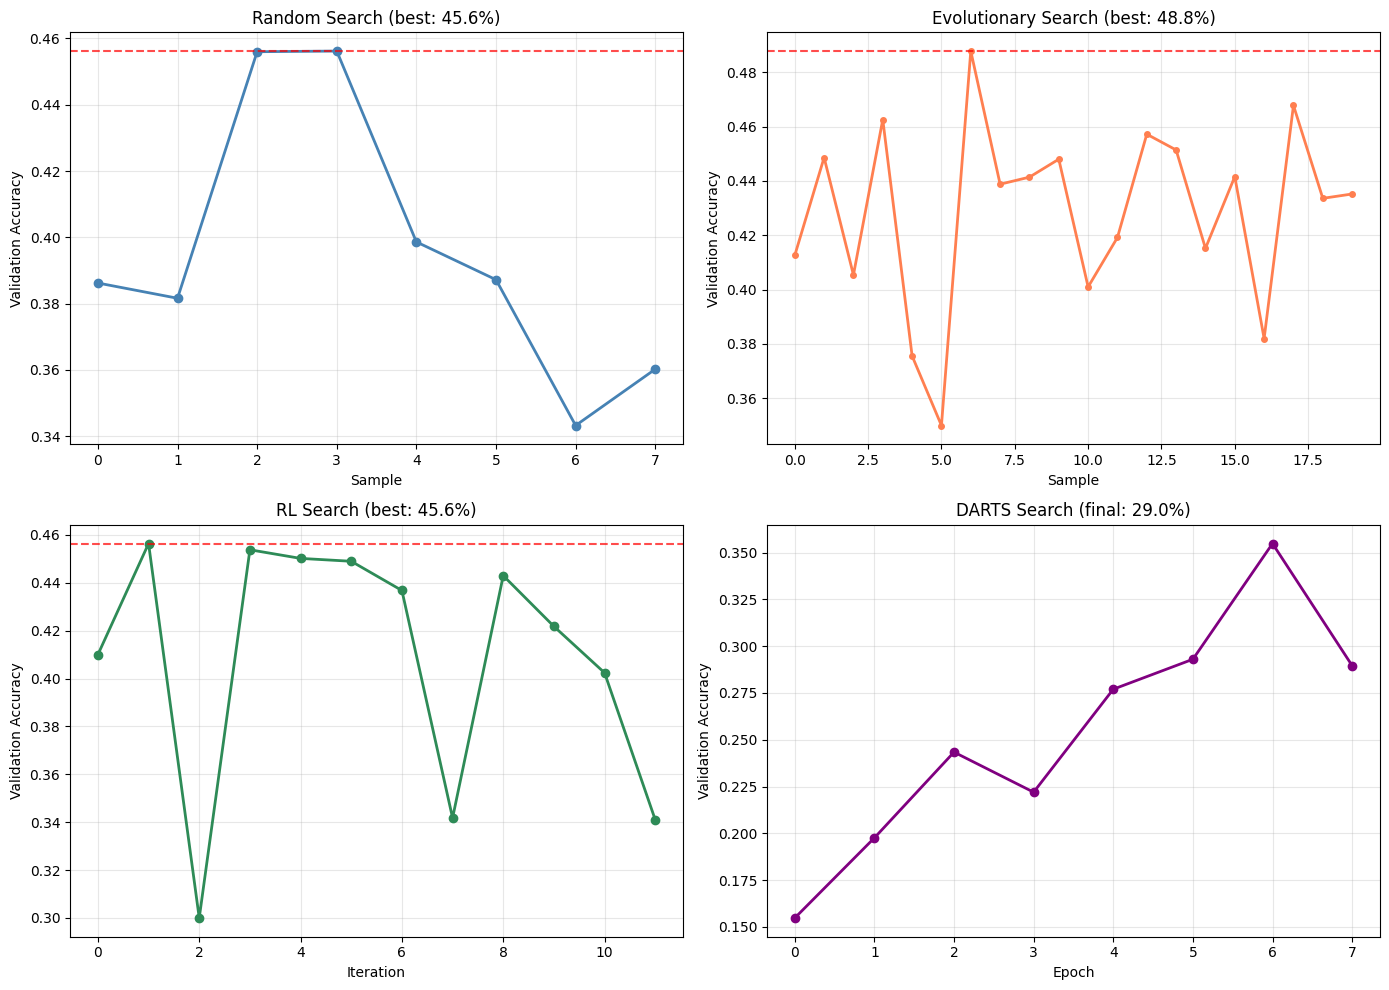

In [77]:
# Visualize search progress

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Random search
ax = axes[0, 0]
accs = [h['accuracy'] for h in random_searcher.history]
ax.plot(accs, 'o-', color='steelblue', linewidth=2)
ax.axhline(max(accs), color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Sample')
ax.set_ylabel('Validation Accuracy')
ax.set_title(f'Random Search (best: {100*max(accs):.1f}%)')
ax.grid(True, alpha=0.3)

# Evolutionary search
ax = axes[0, 1]
accs = [h['accuracy'] for h in evo_searcher.history]
ax.plot(accs, 'o-', color='coral', linewidth=2, markersize=4)
ax.axhline(max(accs), color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Sample')
ax.set_ylabel('Validation Accuracy')
ax.set_title(f'Evolutionary Search (best: {100*max(accs):.1f}%)')
ax.grid(True, alpha=0.3)

# RL search
ax = axes[1, 0]
accs = [h['accuracy'] for h in rl_searcher.history]
ax.plot(accs, 'o-', color='seagreen', linewidth=2)
ax.axhline(max(accs), color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Validation Accuracy')
ax.set_title(f'RL Search (best: {100*max(accs):.1f}%)')
ax.grid(True, alpha=0.3)

# DARTS search
ax = axes[1, 1]
accs = [h['val_acc'] for h in darts_searcher.history]
ax.plot(accs, 'o-', color='purple', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title(f'DARTS Search (final: {100*accs[-1]:.1f}%)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nas_comparison.png', dpi=150, bbox_inches='tight')
plt.show()